In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV,
                                     learning_curve)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             roc_curve, precision_recall_curve,
                             ConfusionMatrixDisplay)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

In [2]:
path = kagglehub.dataset_download(
    "uciml/glass")
print("📁 Path to dataset files:", path)

csv_file = os.path.join(path, "glass.csv")
df = pd.read_csv(csv_file)

print(f"\n✅ Dataset Loaded!")
print(f"📐 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)

Using Colab cache for faster access to the 'glass' dataset.
📁 Path to dataset files: /kaggle/input/glass

✅ Dataset Loaded!
📐 Shape: 214 rows × 10 columns


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.00,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.00,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.00,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.00,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.00,1
5,1.51596,12.79,3.61,1.62,72.97,0.64,8.07,0.0,0.26,1
6,1.51743,13.30,3.60,1.14,73.09,0.58,8.17,0.0,0.00,1
7,1.51756,13.15,3.61,1.05,73.24,0.57,8.24,0.0,0.00,1
8,1.51918,14.04,3.58,1.37,72.08,0.56,8.30,0.0,0.00,1
9,1.51755,13.00,3.60,1.36,72.99,0.57,8.40,0.0,0.11,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RI,214.0,1.518365,0.003037,1.51115,1.516522,1.51768,1.519157,1.53393
Na,214.0,13.407850,0.816604,10.73000,12.907500,13.30000,13.825000,17.38000
Mg,214.0,2.684533,1.442408,0.00000,2.115000,3.48000,3.600000,4.49000
Al,214.0,1.444907,0.499270,0.29000,1.190000,1.36000,1.630000,3.50000
Si,214.0,72.650935,0.774546,69.81000,72.280000,72.79000,73.087500,75.41000
K,214.0,0.497056,0.652192,0.00000,0.122500,0.55500,0.610000,6.21000
Ca,214.0,8.956963,1.423153,5.43000,8.240000,8.60000,9.172500,16.19000
Ba,214.0,0.175047,0.497219,0.00000,0.000000,0.00000,0.000000,3.15000
Fe,214.0,0.057009,0.097439,0.00000,0.000000,0.00000,0.100000,0.51000
Type,214.0,2.780374,2.103739,1.00000,1.000000,2.00000,3.000000,7.00000


In [5]:
num_features = df.select_dtypes(
    include=[np.number]).columns.tolist()
cat_features = df.select_dtypes(
    include=['object']).columns.tolist()

In [6]:
print(f"\n🔢 Numerical Columns ({len(num_features)}):")
for col in num_features:
    print(f"   → {col}: min={df[col].min():.3f}, "
          f"max={df[col].max():.3f}, "
          f"mean={df[col].mean():.3f}")

print(f"\n🔤 Categorical Columns ({len(cat_features)}):")
print(cat_features if cat_features else "None")

print(f"\n🎯 Target: Type (Glass Type)")
print(df['Type'].value_counts().sort_index())

# Glass type description
glass_types = {
    1: 'Building Windows (Float)',
    2: 'Building Windows (Non-Float)',
    3: 'Vehicle Windows (Float)',
    4: 'Vehicle Windows (Non-Float)',
    5: 'Containers',
    6: 'Tableware',
    7: 'Headlamps'
}
print("\n📌 Glass Type Description:")
for k, v in glass_types.items():
    count = (df['Type'] == k).sum()
    print(f"   Type {k}: {v:<35} → {count} samples")


🔢 Numerical Columns (10):
   → RI: min=1.511, max=1.534, mean=1.518
   → Na: min=10.730, max=17.380, mean=13.408
   → Mg: min=0.000, max=4.490, mean=2.685
   → Al: min=0.290, max=3.500, mean=1.445
   → Si: min=69.810, max=75.410, mean=72.651
   → K: min=0.000, max=6.210, mean=0.497
   → Ca: min=5.430, max=16.190, mean=8.957
   → Ba: min=0.000, max=3.150, mean=0.175
   → Fe: min=0.000, max=0.510, mean=0.057
   → Type: min=1.000, max=7.000, mean=2.780

🔤 Categorical Columns (0):
None

🎯 Target: Type (Glass Type)
Type
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64

📌 Glass Type Description:
   Type 1: Building Windows (Float)            → 70 samples
   Type 2: Building Windows (Non-Float)        → 76 samples
   Type 3: Vehicle Windows (Float)             → 17 samples
   Type 4: Vehicle Windows (Non-Float)         → 0 samples
   Type 5: Containers                          → 13 samples
   Type 6: Tableware                           → 9 samples
   Type 7: Headlamp

In [7]:
print("🔍 Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values found!")
else:
    print(missing[missing > 0])
    df.fillna(df.median(numeric_only=True), inplace=True)
    print("✅ Filled with median")

🔍 Missing Values:
✅ No missing values found!


In [8]:
dups = df.duplicated().sum()
print(f"\n🔍 Duplicate rows: {dups}")
if dups > 0:
    df.drop_duplicates(inplace=True)
    print("✅ Duplicates removed!")
else:
    print("✅ No duplicates found!")


🔍 Duplicate rows: 1
✅ Duplicates removed!


In [9]:
useless = [c for c in df.columns
           if df[c].nunique() == 1]
if useless:
    df.drop(columns=useless, inplace=True)
    print(f"✅ Dropped constant cols: {useless}")
else:
    print("✅ No constant columns!")

✅ No constant columns!


In [10]:
obj_cols = df.select_dtypes(include='object').columns
df[obj_cols] = df[obj_cols].apply(
    lambda x: x.str.strip())
print("✅ Whitespace stripped")

✅ Whitespace stripped


In [11]:
print("\n🔍 Outlier Detection (IQR Method):")
feature_cols = [c for c in df.columns if c != 'Type']
outlier_info = {}

for col in feature_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower    = Q1 - 1.5 * IQR
    upper    = Q3 + 1.5 * IQR
    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)].shape[0]
    if outliers > 0:
        outlier_info[col] = outliers

print(f"  Columns with outliers: {len(outlier_info)}")
for col, count in outlier_info.items():
    print(f"  → {col}: {count} outliers")

# Winsorization
for col in outlier_info.keys():
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(
        lower=Q1 - 1.5 * IQR,
        upper=Q3 + 1.5 * IQR)
print("✅ Outliers capped (Winsorization)")

print(f"\n📐 Cleaned Shape: {df.shape}")
df.head(3)


🔍 Outlier Detection (IQR Method):
  Columns with outliers: 8
  → RI: 17 outliers
  → Na: 7 outliers
  → Al: 17 outliers
  → Si: 12 outliers
  → K: 7 outliers
  → Ca: 27 outliers
  → Ba: 38 outliers
  → Fe: 12 outliers
✅ Outliers capped (Winsorization)

📐 Cleaned Shape: (213, 10)


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1


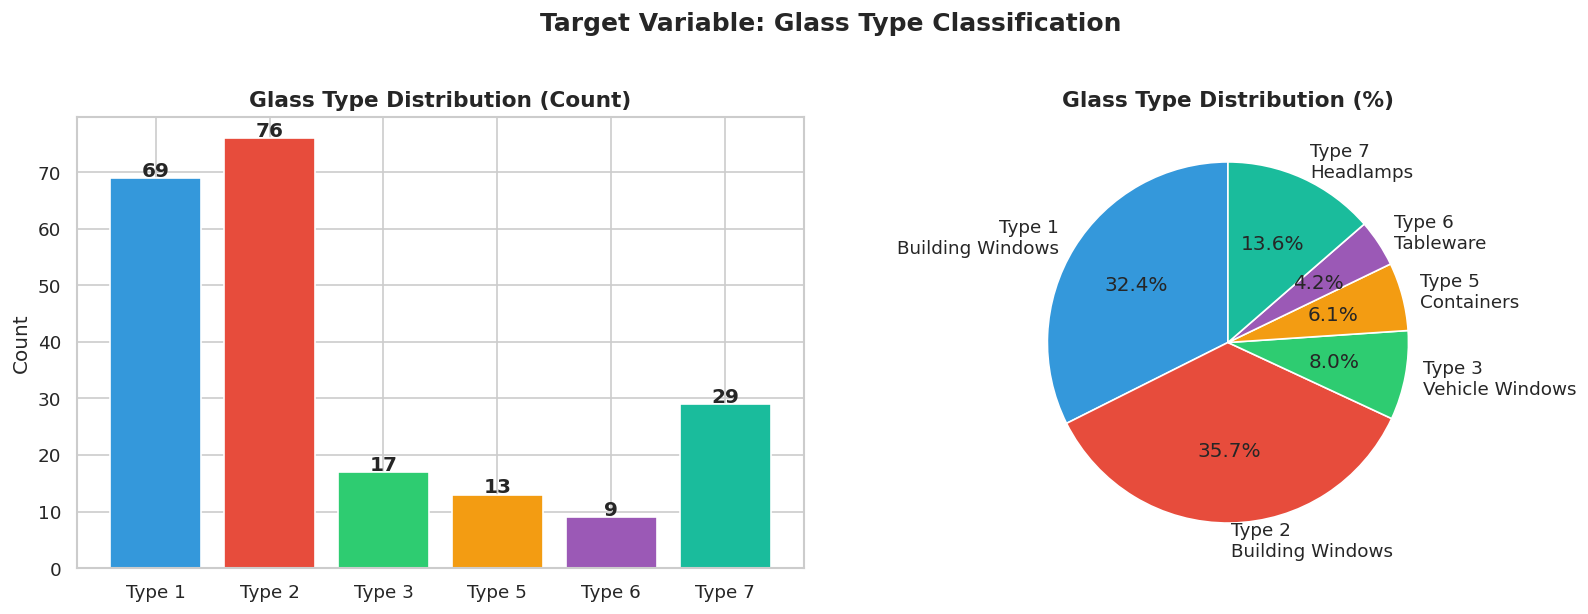

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_counts = df['Type'].value_counts().sort_index()
type_labels = [f"Type {k}\n{glass_types[k].split('(')[0].strip()}"
               for k in type_counts.index]

colors_pie = ['#3498db', '#e74c3c', '#2ecc71',
              '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

axes[0].bar(range(len(type_counts)),
            type_counts.values,
            color=colors_pie[:len(type_counts)],
            edgecolor='white')
axes[0].set_title('Glass Type Distribution (Count)',
                  fontsize=13, fontweight='bold')
axes[0].set_xticks(range(len(type_counts)))
axes[0].set_xticklabels(
    [f"Type {k}" for k in type_counts.index],
    rotation=0)
axes[0].set_ylabel('Count')
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 0.3, str(v),
                 ha='center', fontweight='bold')

axes[1].pie(type_counts.values,
            labels=type_labels,
            autopct='%1.1f%%',
            colors=colors_pie[:len(type_counts)],
            startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Glass Type Distribution (%)',
                  fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Glass Type Classification',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('KNN_01_type_distribution.png',
            bbox_inches='tight')
plt.show()

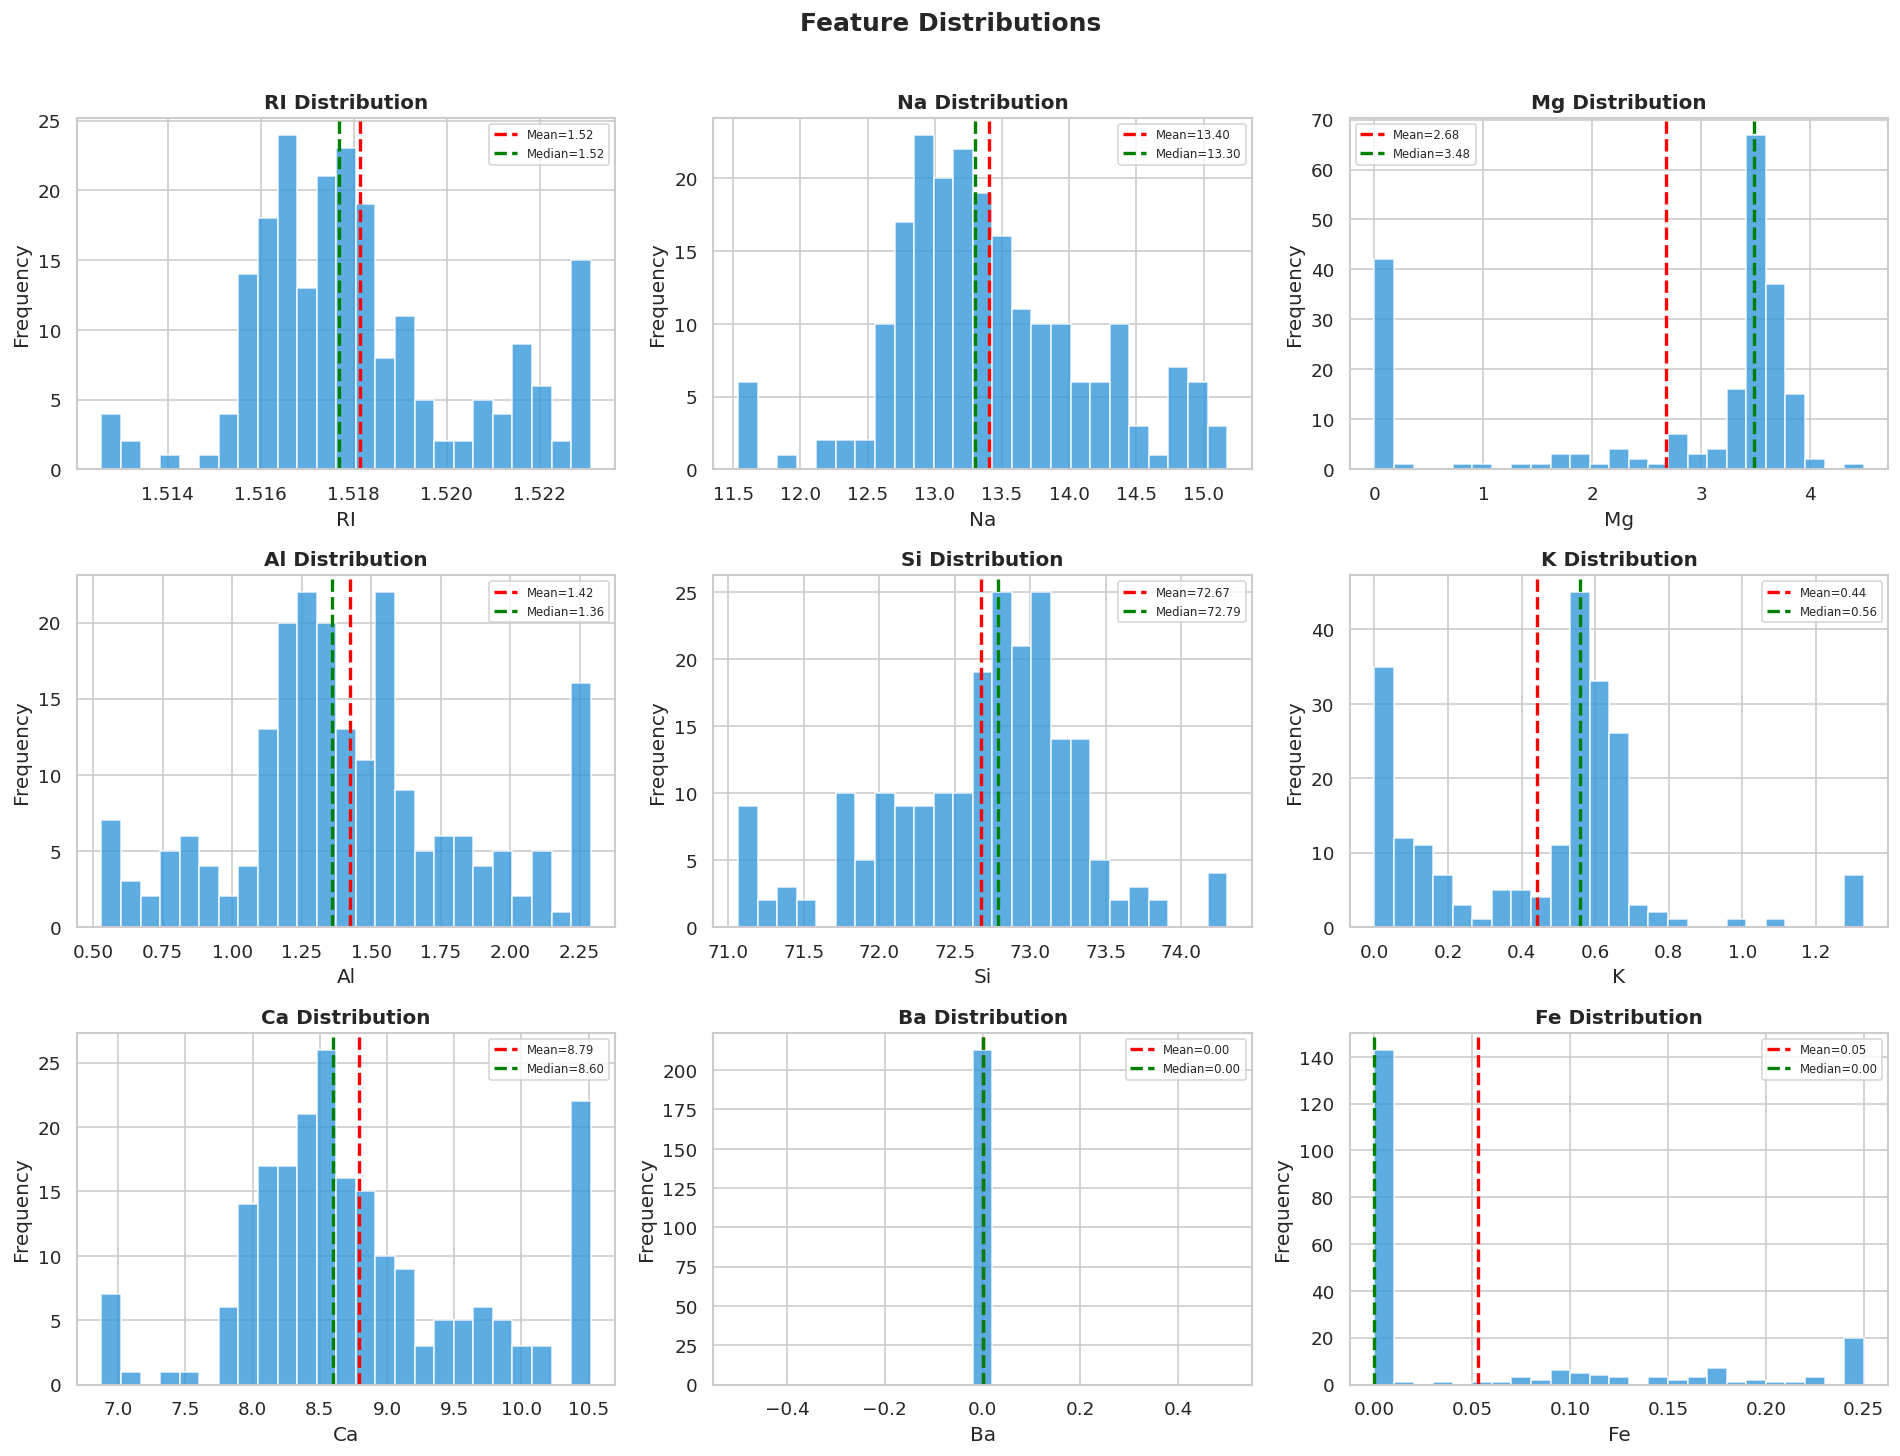

In [13]:
feature_cols = [c for c in df.columns if c != 'Type']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=25,
                 color='#3498db', edgecolor='white',
                 alpha=0.8)
    axes[i].axvline(df[col].mean(), color='red',
                    linestyle='--', lw=2,
                    label=f'Mean={df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='green',
                    linestyle='--', lw=2,
                    label=f'Median={df[col].median():.2f}')
    axes[i].set_title(f'{col} Distribution',
                      fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('KNN_02_feature_distributions.png',
            bbox_inches='tight')
plt.show()

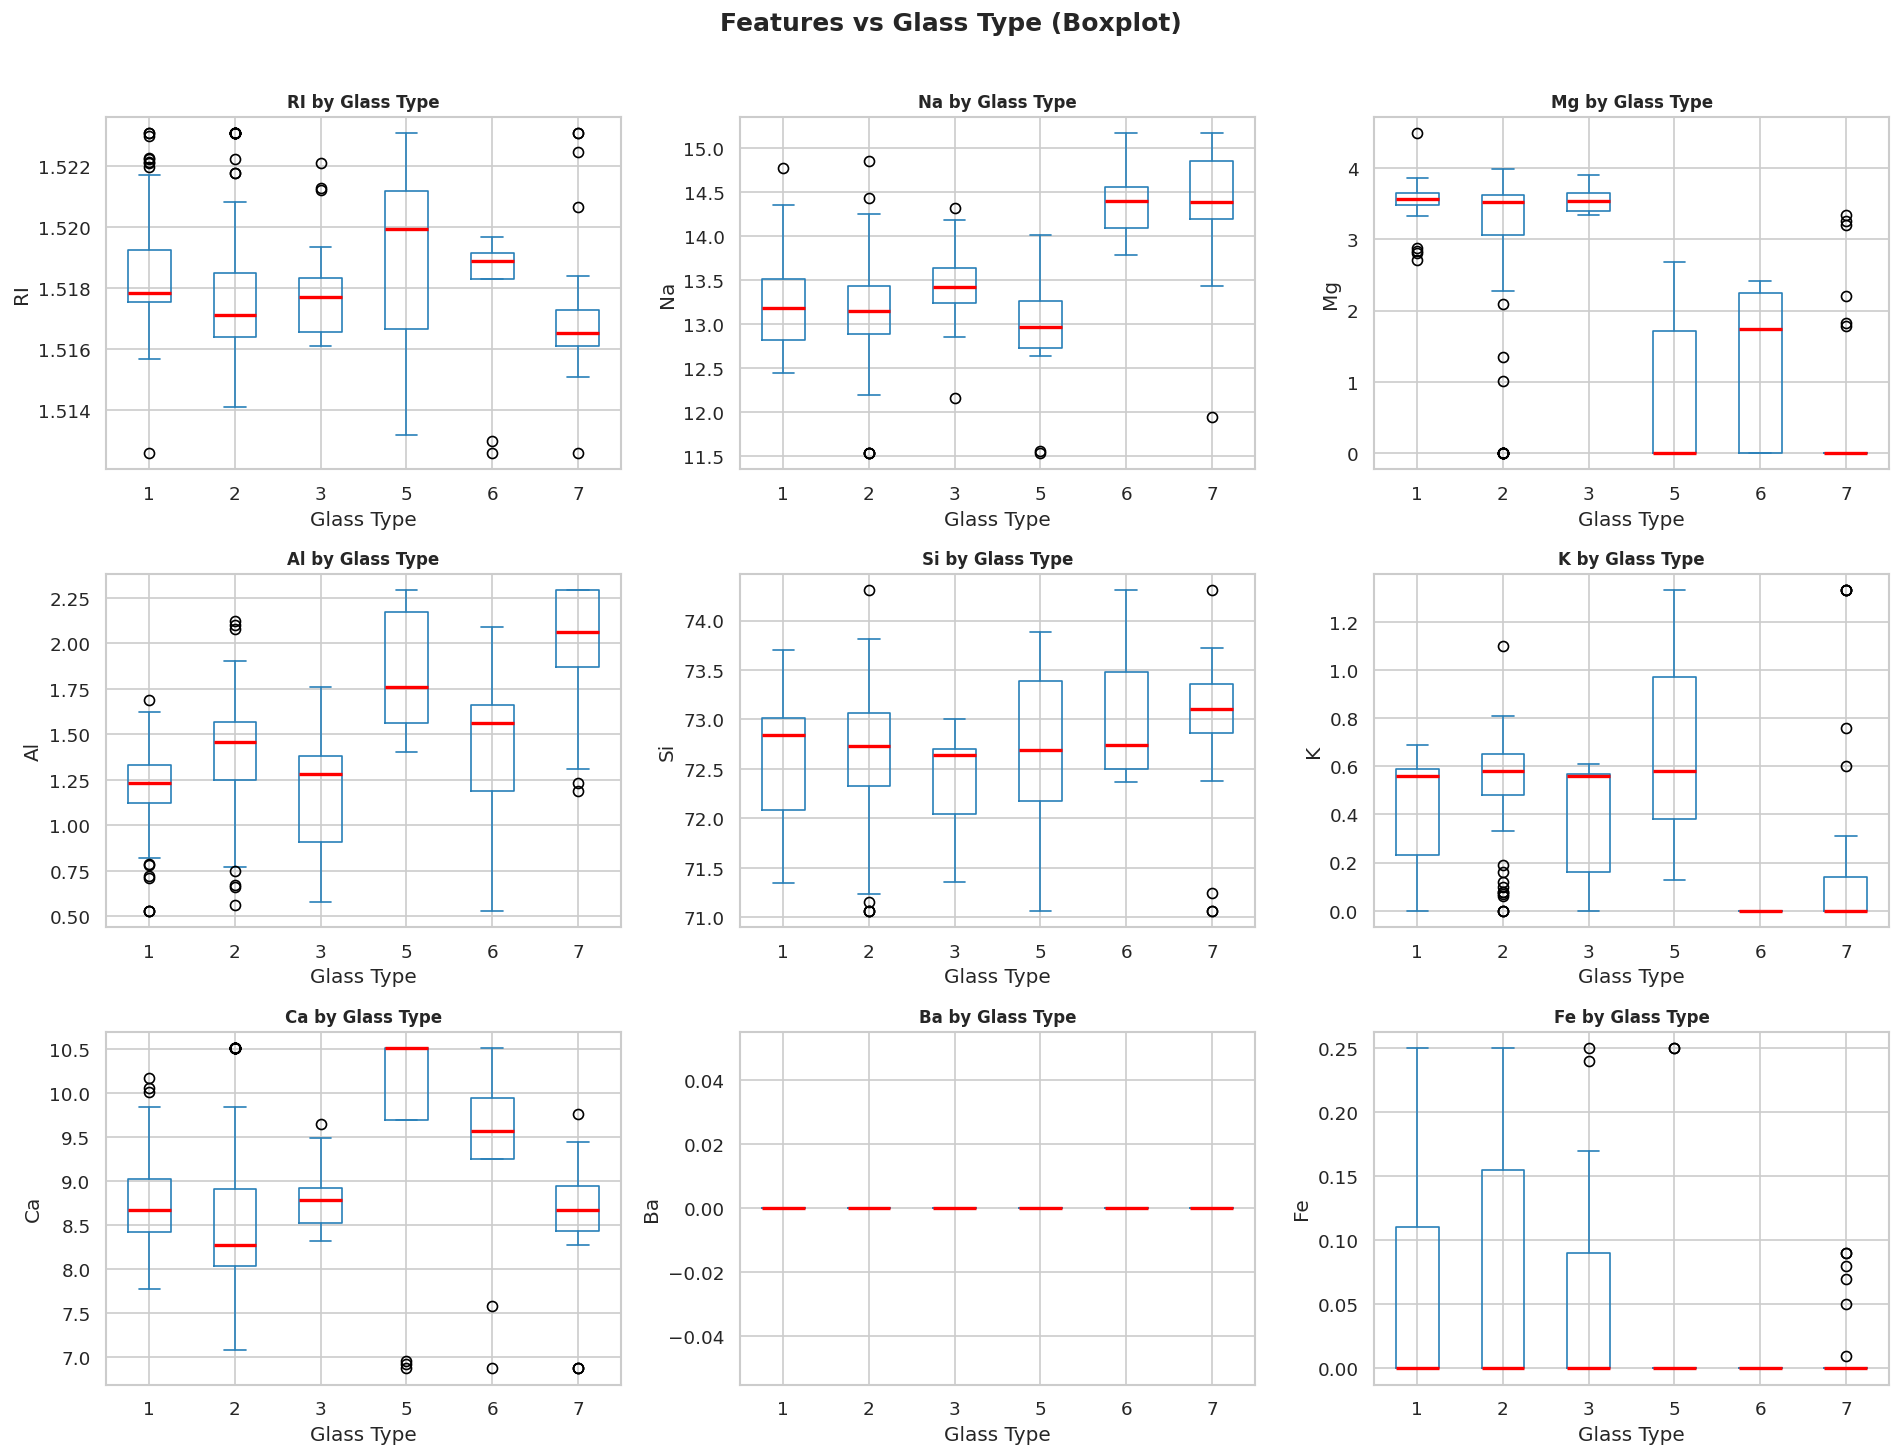

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    df.boxplot(column=col, by='Type', ax=axes[i],
               boxprops=dict(color='#2980b9'),
               medianprops=dict(color='red',
                                linewidth=2),
               whiskerprops=dict(color='#2980b9'),
               capprops=dict(color='#2980b9'))
    axes[i].set_title(f'{col} by Glass Type',
                      fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Glass Type')
    axes[i].set_ylabel(col)

plt.suptitle('Features vs Glass Type (Boxplot)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('KNN_03_boxplots.png', bbox_inches='tight')
plt.show()

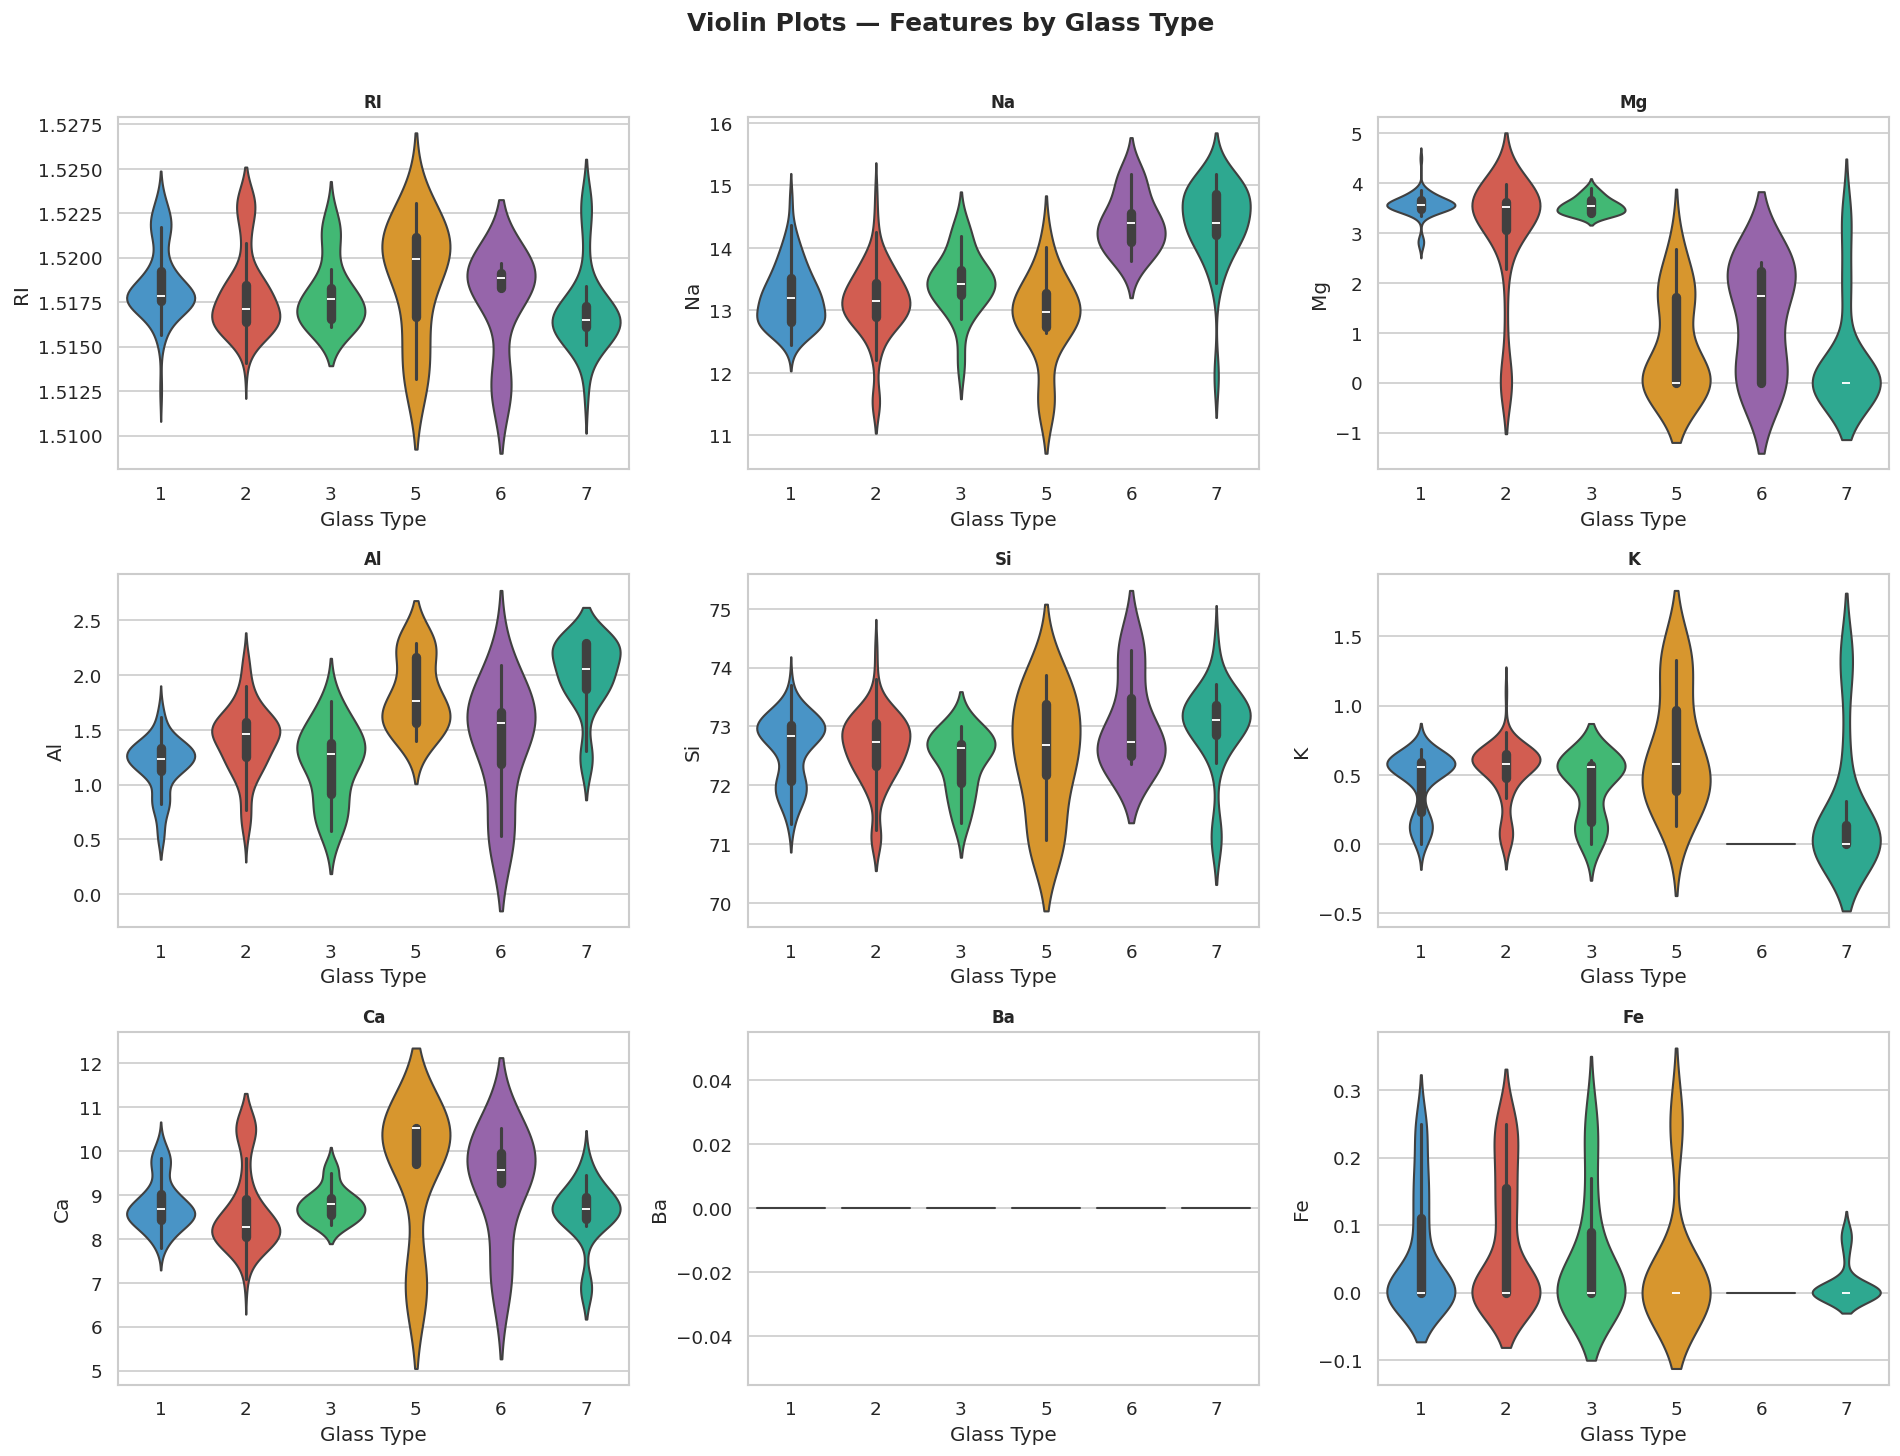

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.violinplot(
        data=df, x='Type', y=col,
        palette=colors_pie[:df['Type'].nunique()],
        ax=axes[i], inner='box')
    axes[i].set_title(f'{col}',
                      fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Glass Type')

plt.suptitle('Violin Plots — Features by Glass Type',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('KNN_04_violin_plots.png',
            bbox_inches='tight')
plt.show()

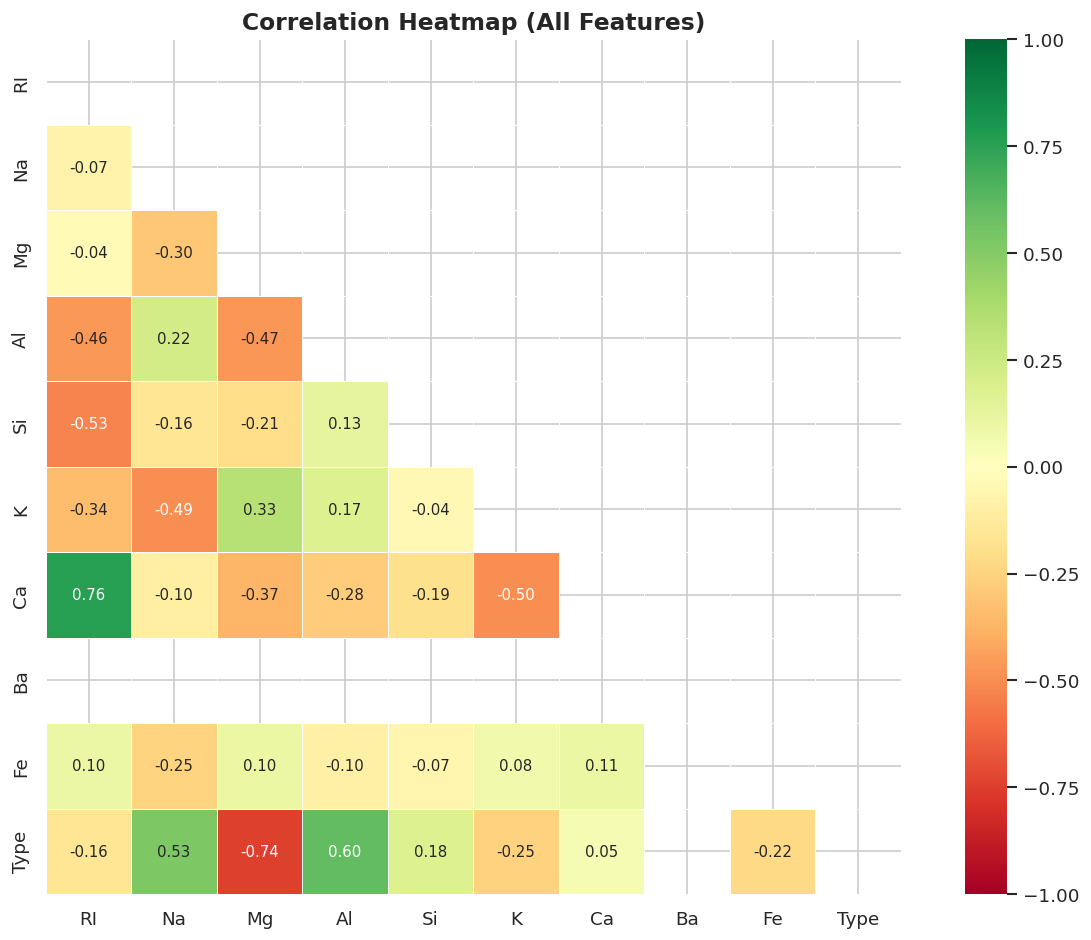

In [16]:
fig, ax = plt.subplots(figsize=(11, 8))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask,
            annot=True, fmt='.2f',
            cmap='RdYlGn',
            linewidths=0.4, ax=ax,
            annot_kws={'fontsize': 9},
            vmin=-1, vmax=1,
            center=0, square=True)
ax.set_title('Correlation Heatmap (All Features)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('KNN_05_correlation_heatmap.png',
            bbox_inches='tight')
plt.show()

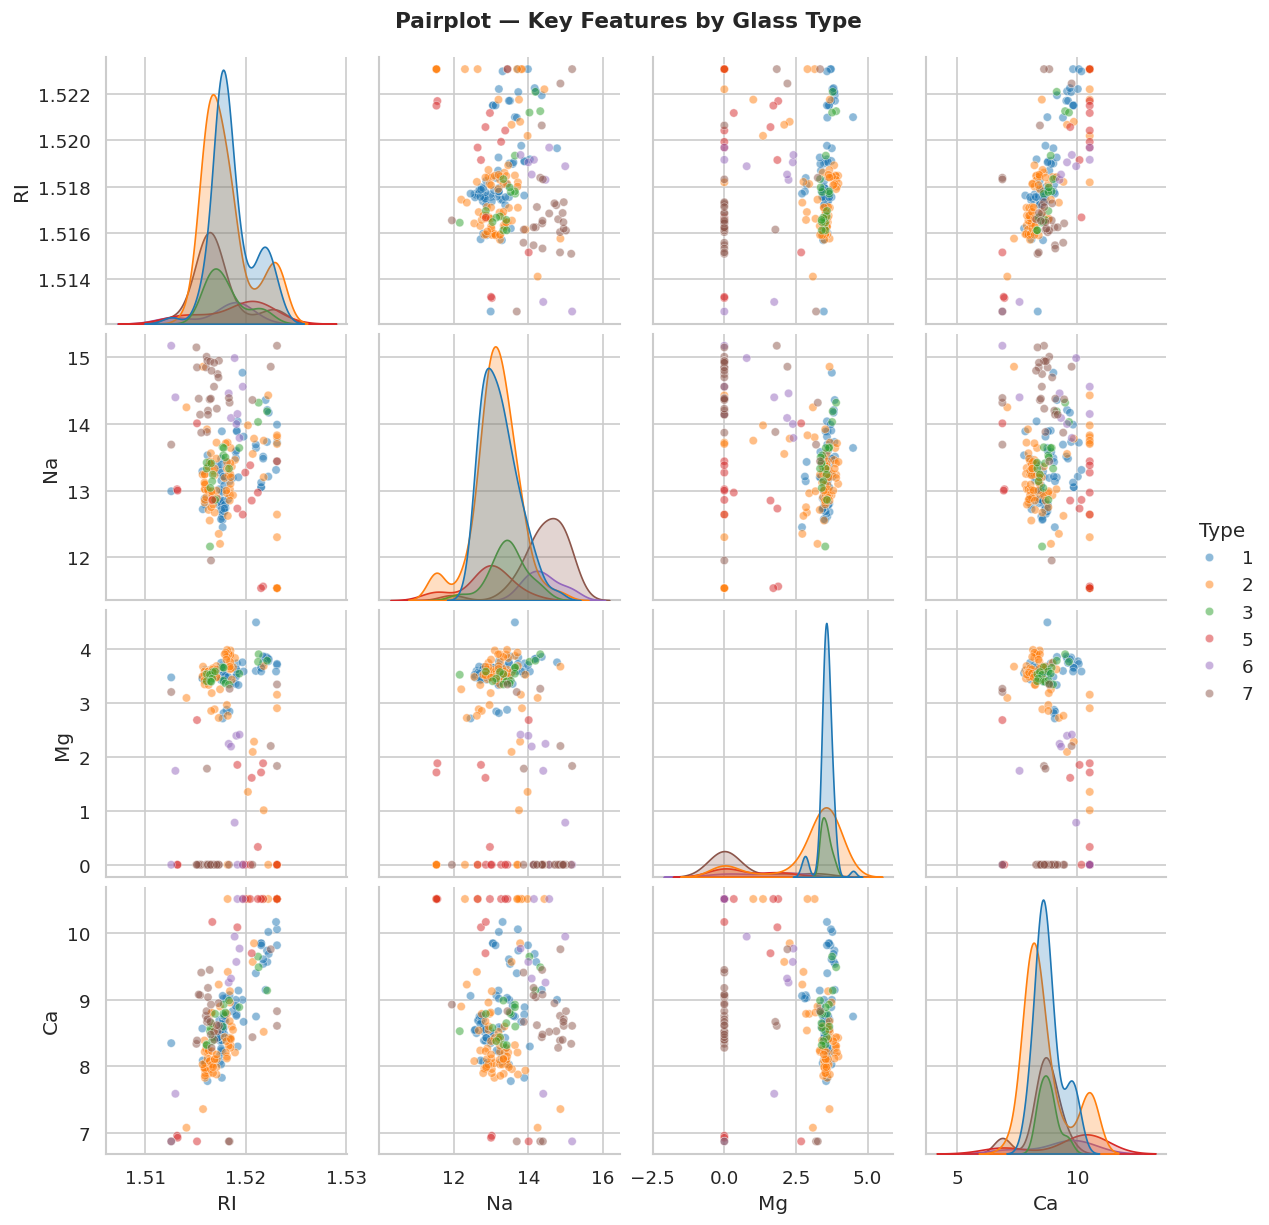

In [17]:
top_features = ['RI', 'Na', 'Mg', 'Ca', 'Type']

df_pair = df[top_features].copy()
df_pair['Type'] = df_pair['Type'].astype(str)

pair_grid = sns.pairplot(
    df_pair, hue='Type',
    palette='tab10',
    plot_kws={'alpha': 0.5, 's': 25},
    diag_kind='kde')
pair_grid.fig.suptitle(
    'Pairplot — Key Features by Glass Type',
    fontsize=13, fontweight='bold', y=1.02)
plt.savefig('KNN_06_pairplot.png', bbox_inches='tight')
plt.show()

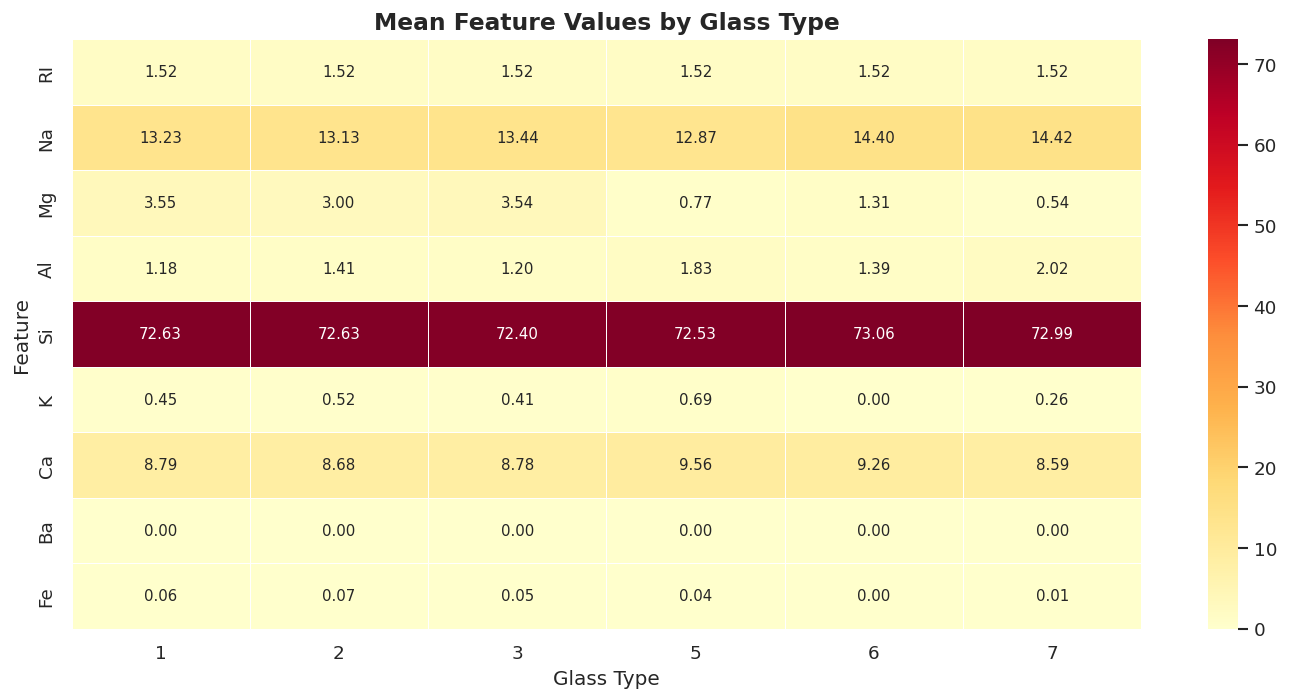

In [18]:
mean_by_type = df.groupby('Type')[feature_cols].mean()

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    mean_by_type.T,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.4,
    ax=ax,
    annot_kws={'fontsize': 9})
ax.set_title('Mean Feature Values by Glass Type',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Glass Type')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('KNN_07_mean_heatmap.png',
            bbox_inches='tight')
plt.show()

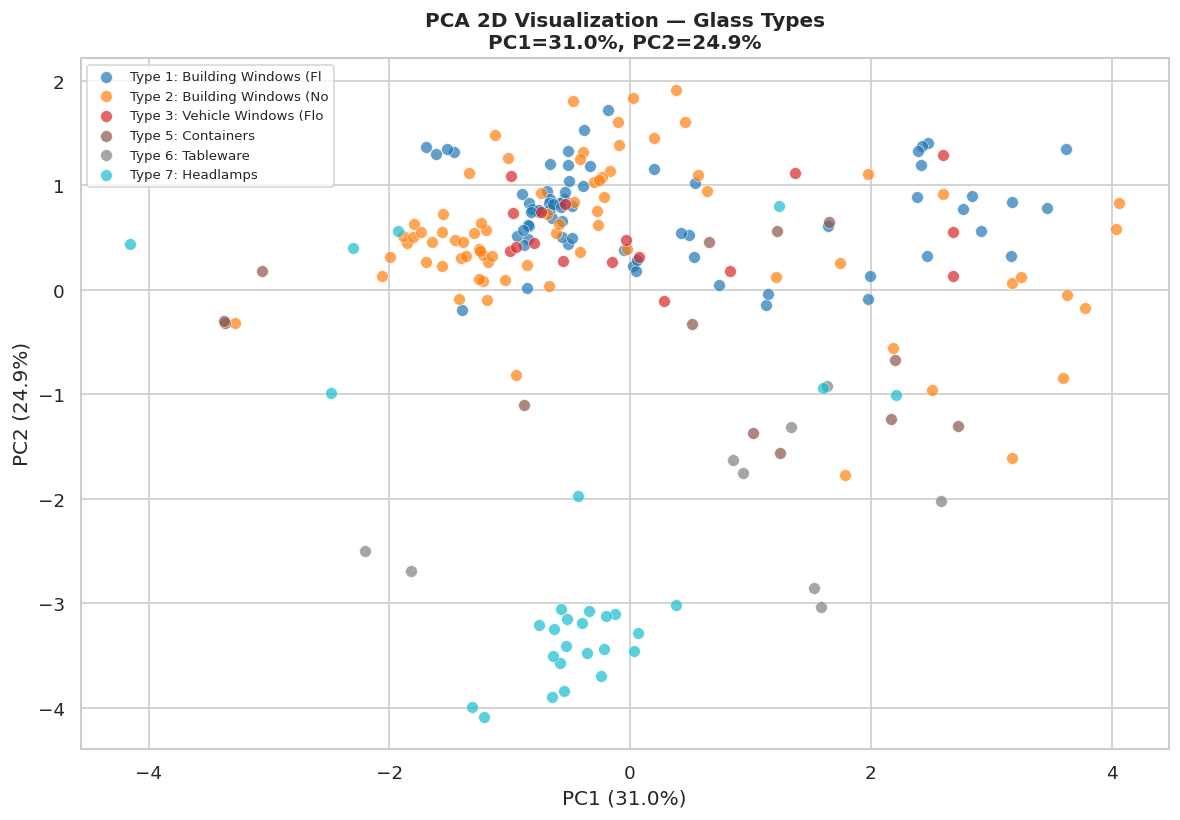

In [19]:
X_vis = df[feature_cols]
y_vis = df['Type']

sc_vis  = StandardScaler()
X_sc_vis = sc_vis.fit_transform(X_vis)

pca_vis = PCA(n_components=2, random_state=42)
X_pca   = pca_vis.fit_transform(X_sc_vis)

fig, ax = plt.subplots(figsize=(10, 7))

unique_types = sorted(df['Type'].unique())
palette      = plt.cm.tab10(
    np.linspace(0, 0.9, len(unique_types)))

for t, color in zip(unique_types, palette):
    mask = y_vis == t
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[color], label=f'Type {t}: '
               f'{glass_types[t][:20]}',
               alpha=0.7, s=50,
               edgecolors='white', linewidths=0.4)

ax.set_title(
    f'PCA 2D Visualization — Glass Types\n'
    f'PC1={pca_vis.explained_variance_ratio_[0]*100:.1f}%'
    f', PC2={pca_vis.explained_variance_ratio_[1]*100:.1f}%',
    fontsize=12, fontweight='bold')
ax.set_xlabel(
    f'PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(
    f'PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.savefig('KNN_08_pca_2d.png', bbox_inches='tight')
plt.show()

In [20]:
df_model = df.copy()

# ── 6.1 Target stays as is (multi-class)
print("✅ Target (Type) kept as multi-class")
print(f"   Classes: {sorted(df_model['Type'].unique())}")

# ── 6.2 No categorical features here
# All features already numeric
print("✅ All features are numerical — no encoding needed")

# ── 6.3 Handle remaining nulls
df_model.fillna(
    df_model.median(numeric_only=True), inplace=True)
print("✅ Null values handled")

print(f"\n📐 Shape after processing: {df_model.shape}")
df_model.head(3)

✅ Target (Type) kept as multi-class
   Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7)]
✅ All features are numerical — no encoding needed
✅ Null values handled

📐 Shape after processing: (213, 10)


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1


In [21]:
# Na-Ca ratio (glass composition indicator)
df_model['Na_Ca_ratio'] = (
    df_model['Na'] /
    (df_model['Ca'] + 1e-5))
print("✅ 'Na_Ca_ratio' created")

# Si-Al ratio
df_model['Si_Al_ratio'] = (
    df_model['Si'] /
    (df_model['Al'] + 1e-5))
print("✅ 'Si_Al_ratio' created")

# Refractive index normalized
df_model['RI_Na_product'] = (
    df_model['RI'] * df_model['Na'])
print("✅ 'RI_Na_product' created")

# Metal oxide sum
metal_oxides = ['Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']
available_ox = [c for c in metal_oxides
                if c in df_model.columns]
df_model['total_oxide'] = df_model[available_ox].sum(axis=1)
print("✅ 'total_oxide' created")

# Mg to Ca ratio
df_model['Mg_Ca_ratio'] = (
    df_model['Mg'] /
    (df_model['Ca'] + 1e-5))
print("✅ 'Mg_Ca_ratio' created")

print(f"\n📐 Final Shape: {df_model.shape}")

✅ 'Na_Ca_ratio' created
✅ 'Si_Al_ratio' created
✅ 'RI_Na_product' created
✅ 'total_oxide' created
✅ 'Mg_Ca_ratio' created

📐 Final Shape: (213, 15)


In [22]:
X = df_model.drop(columns=['Type'])
y = df_model['Type']

print(f"🎯 Target distribution:")
for t in sorted(y.unique()):
    print(f"   Type {t}: {(y==t).sum()} samples")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size   = 0.2,
    random_state= 42,
    stratify    = y)

# ⚠️ KNN MUST have scaling
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\n✅ Training set  : {X_train_sc.shape}")
print(f"✅ Test set      : {X_test_sc.shape}")
print(f"✅ Features      : {X_train_sc.shape[1]}")
print("\n⚠️  StandardScaler APPLIED!")

🎯 Target distribution:
   Type 1: 69 samples
   Type 2: 76 samples
   Type 3: 17 samples
   Type 5: 13 samples
   Type 6: 9 samples
   Type 7: 29 samples

✅ Training set  : (170, 14)
✅ Test set      : (43, 14)
✅ Features      : 14

⚠️  StandardScaler APPLIED!


In [23]:
k_range     = range(1, 31)
train_accs  = []
test_accs   = []
cv_scores_k = []

for k in k_range:
    knn_temp = KNeighborsClassifier(
        n_neighbors=k,
        metric='minkowski',
        p=2)
    knn_temp.fit(X_train_sc, y_train)

    train_accs.append(
        accuracy_score(y_train,
                       knn_temp.predict(X_train_sc)))
    test_accs.append(
        accuracy_score(y_test,
                       knn_temp.predict(X_test_sc)))
    cv_s = cross_val_score(
        knn_temp, X_train_sc, y_train,
        cv=StratifiedKFold(5),
        scoring='accuracy')
    cv_scores_k.append(cv_s.mean())

best_k_cv   = k_range[np.argmax(cv_scores_k)]
best_k_test = k_range[np.argmax(test_accs)]

print(f"✅ Best K (CV Score)   : {best_k_cv}")
print(f"✅ Best K (Test Acc)   : {best_k_test}")
print(f"✅ Best CV Accuracy    : {max(cv_scores_k)*100:.2f}%")
print(f"✅ Best Test Accuracy  : {max(test_accs)*100:.2f}%")

✅ Best K (CV Score)   : 1
✅ Best K (Test Acc)   : 3
✅ Best CV Accuracy    : 69.41%
✅ Best Test Accuracy  : 79.07%


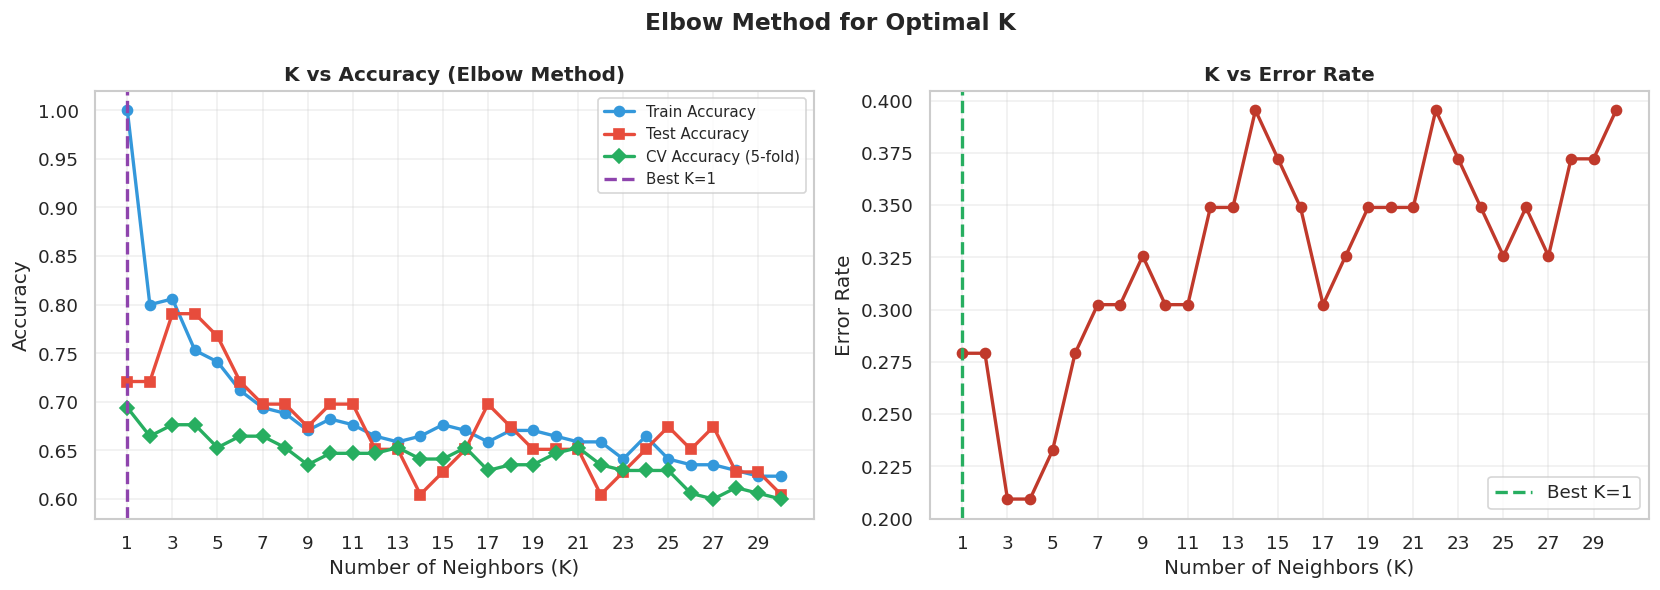

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy vs K
axes[0].plot(k_range, train_accs, 'o-',
             color='#3498db', lw=2,
             label='Train Accuracy')
axes[0].plot(k_range, test_accs, 's-',
             color='#e74c3c', lw=2,
             label='Test Accuracy')
axes[0].plot(k_range, cv_scores_k, 'D-',
             color='#27ae60', lw=2,
             label='CV Accuracy (5-fold)')
axes[0].axvline(x=best_k_cv, color='#8e44ad',
                linestyle='--', lw=2,
                label=f'Best K={best_k_cv}')
axes[0].set_title('K vs Accuracy (Elbow Method)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Neighbors (K)')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(1, 31, 2))

# Error Rate vs K
error_rate = [1 - acc for acc in test_accs]
axes[1].plot(k_range, error_rate, 'o-',
             color='#c0392b', lw=2)
axes[1].axvline(x=best_k_cv, color='#27ae60',
                linestyle='--', lw=2,
                label=f'Best K={best_k_cv}')
axes[1].set_title('K vs Error Rate',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Neighbors (K)')
axes[1].set_ylabel('Error Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(1, 31, 2))

plt.suptitle('Elbow Method for Optimal K',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('KNN_09_elbow_method.png',
            bbox_inches='tight')
plt.show()

In [25]:
metrics      = ['euclidean', 'manhattan',
                'chebyshev', 'minkowski']
metric_res   = {}

for metric in metrics:
    knn_m = KNeighborsClassifier(
        n_neighbors = best_k_cv,
        metric      = metric)
    knn_m.fit(X_train_sc, y_train)
    acc_m = accuracy_score(
        y_test, knn_m.predict(X_test_sc))
    cv_m  = cross_val_score(
        knn_m, X_train_sc, y_train,
        cv=StratifiedKFold(5),
        scoring='accuracy').mean()
    metric_res[metric] = {
        'acc': acc_m, 'cv': cv_m}
    print(f"  {metric:<15} → "
          f"Acc: {acc_m*100:.2f}%  "
          f"CV: {cv_m*100:.2f}%")

best_metric = max(metric_res,
                  key=lambda m: metric_res[m]['cv'])
print(f"\n🏆 Best Distance Metric: {best_metric}")

  euclidean       → Acc: 72.09%  CV: 69.41%
  manhattan       → Acc: 74.42%  CV: 72.94%
  chebyshev       → Acc: 69.77%  CV: 67.65%
  minkowski       → Acc: 72.09%  CV: 69.41%

🏆 Best Distance Metric: manhattan


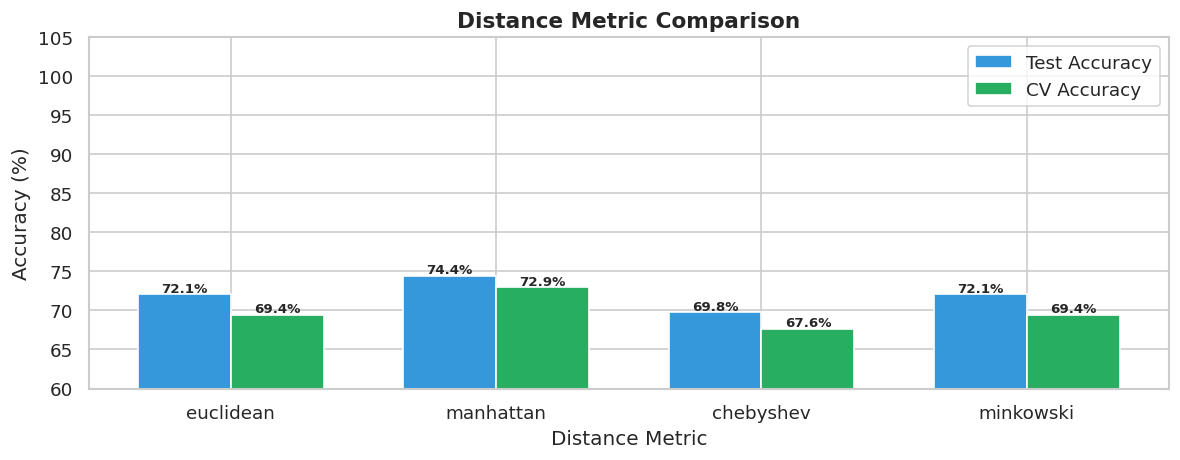

In [26]:
fig, ax = plt.subplots(figsize=(10, 4))

m_names = list(metric_res.keys())
m_acc   = [metric_res[m]['acc'] * 100 for m in m_names]
m_cv    = [metric_res[m]['cv']  * 100 for m in m_names]

x      = np.arange(len(m_names))
width  = 0.35

bars1 = ax.bar(x - width/2, m_acc, width,
               label='Test Accuracy',
               color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, m_cv, width,
               label='CV Accuracy',
               color='#27ae60', edgecolor='white')

ax.set_title('Distance Metric Comparison',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Distance Metric')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(x)
ax.set_xticklabels(m_names)
ax.legend()
ax.set_ylim(60, 105)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=8,
            fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=8,
            fontweight='bold')

plt.tight_layout()
plt.savefig('KNN_10_metric_comparison.png',
            bbox_inches='tight')
plt.show()

In [27]:
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan',
                    'chebyshev', 'minkowski'],
    'p'          : [1, 2]
}

grid_search = GridSearchCV(
    estimator  = KNeighborsClassifier(),
    param_grid = param_grid,
    cv         = StratifiedKFold(5),
    scoring    = 'accuracy',
    n_jobs     = -1,
    verbose    = 1
)
grid_search.fit(X_train_sc, y_train)

print(f"\n✅ Best Parameters  : {grid_search.best_params_}")
print(f"✅ Best CV Accuracy : "
      f"{grid_search.best_score_*100:.2f}%")

Fitting 5 folds for each of 320 candidates, totalling 1600 fits

✅ Best Parameters  : {'metric': 'manhattan', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
✅ Best CV Accuracy : 75.88%


In [28]:
knn_best = grid_search.best_estimator_
knn_best.fit(X_train_sc, y_train)

y_pred      = knn_best.predict(X_test_sc)
y_pred_prob = knn_best.predict_proba(X_test_sc)

acc = accuracy_score(y_test, y_pred)
cv  = cross_val_score(
    knn_best, X_train_sc, y_train,
    cv=StratifiedKFold(5),
    scoring='accuracy')

# ROC-AUC (one-vs-rest for multi-class)
roc = roc_auc_score(
    y_test, y_pred_prob,
    multi_class='ovr',
    average='weighted')

# Baseline KNN
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_sc, y_train)
acc_base = accuracy_score(
    y_test, knn_base.predict(X_test_sc))

print(f"\n{'Metric':<30} {'Baseline':>10} {'Tuned':>10}")
print("-" * 52)
print(f"{'Accuracy':<30} "
      f"{acc_base*100:>9.2f}% {acc*100:>9.2f}%")
print(f"{'ROC-AUC (weighted OvR)':<30} "
      f"{'—':>10} {roc:>10.4f}")
print(f"{'CV Accuracy (mean)':<30} "
      f"{'—':>10} {cv.mean()*100:>9.2f}%")
print(f"{'CV Accuracy (std)':<30} "
      f"{'—':>10} {cv.std()*100:>9.2f}%")
print(f"{'Best K':<30} "
      f"{'5':>10} "
      f"{grid_search.best_params_['n_neighbors']:>10}")
print(f"{'Best Metric':<30} "
      f"{'euclidean':>10} "
      f"{grid_search.best_params_['metric']:>10}")

print(f"\n📋 Classification Report:\n")
type_names = [f"Type {t}" for t in sorted(y.unique())]
print(classification_report(
    y_test, y_pred,
    target_names=type_names))


Metric                           Baseline      Tuned
----------------------------------------------------
Accuracy                           76.74%     76.74%
ROC-AUC (weighted OvR)                  —     0.9251
CV Accuracy (mean)                      —     75.88%
CV Accuracy (std)                       —      2.20%
Best K                                  5          3
Best Metric                     euclidean  manhattan

📋 Classification Report:

              precision    recall  f1-score   support

      Type 1       0.75      0.86      0.80        14
      Type 2       0.92      0.73      0.81        15
      Type 3       0.50      0.33      0.40         3
      Type 5       0.75      1.00      0.86         3
      Type 6       0.50      0.50      0.50         2
      Type 7       0.71      0.83      0.77         6

    accuracy                           0.77        43
   macro avg       0.69      0.71      0.69        43
weighted avg       0.77      0.77      0.76        43



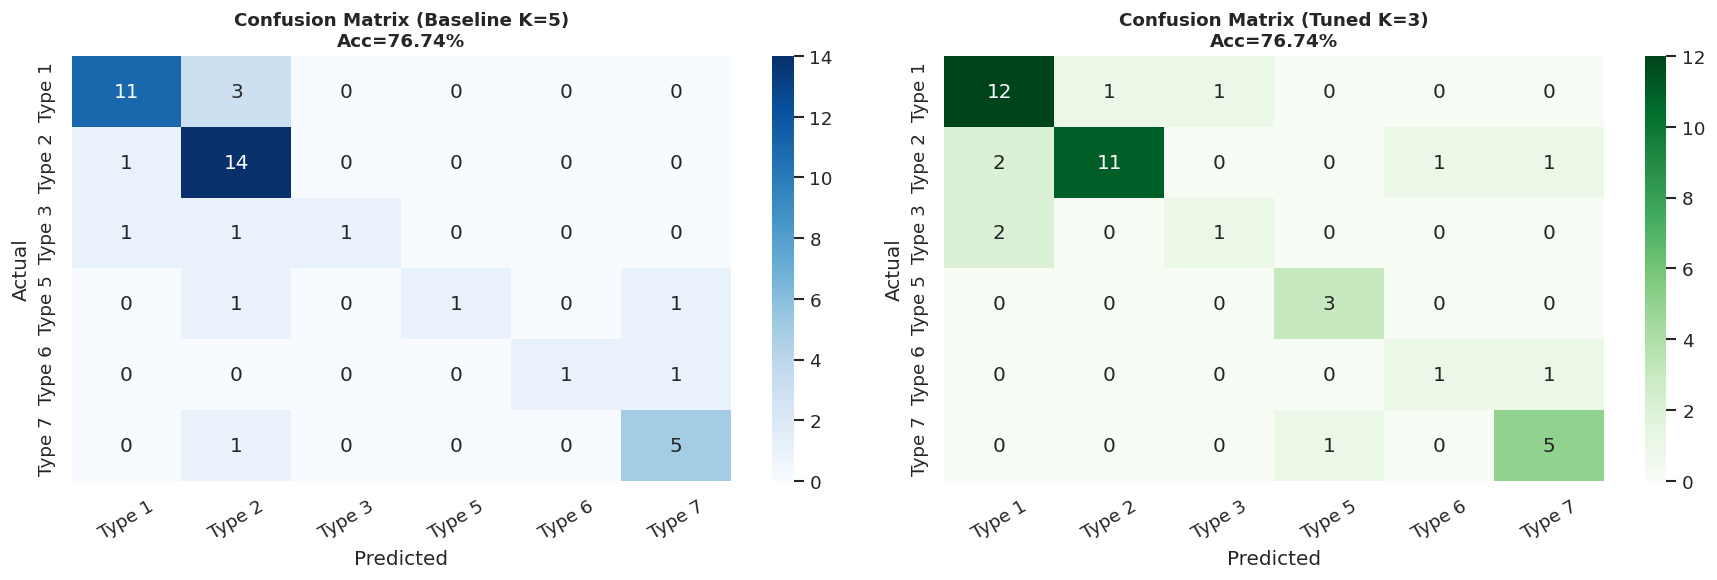

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Baseline CM
cm_base = confusion_matrix(
    y_test, knn_base.predict(X_test_sc))
sns.heatmap(cm_base, annot=True, fmt='d',
            cmap='Blues', ax=axes[0],
            xticklabels=type_names,
            yticklabels=type_names)
axes[0].set_title(f'Confusion Matrix (Baseline K=5)\n'
                  f'Acc={acc_base*100:.2f}%',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=30)

# Tuned CM
cm_tuned = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_tuned, annot=True, fmt='d',
            cmap='Greens', ax=axes[1],
            xticklabels=type_names,
            yticklabels=type_names)
axes[1].set_title(
    f'Confusion Matrix (Tuned K='
    f'{grid_search.best_params_["n_neighbors"]})\n'
    f'Acc={acc*100:.2f}%',
    fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('KNN_11_confusion_matrix.png',
            bbox_inches='tight')
plt.show()

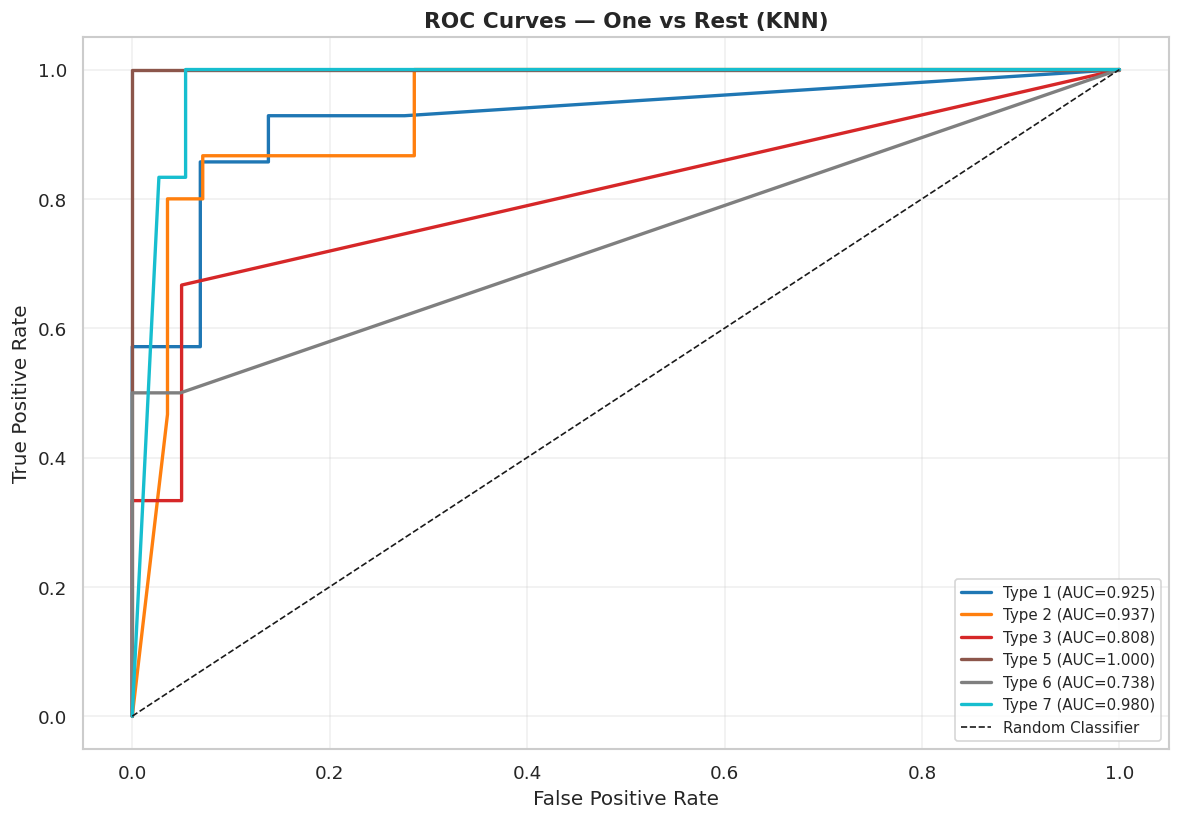

In [30]:
from sklearn.preprocessing import label_binarize

classes   = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)

fig, ax = plt.subplots(figsize=(10, 7))

roc_colors = plt.cm.tab10(
    np.linspace(0, 0.9, len(classes)))

for i, (cls, color) in enumerate(
        zip(classes, roc_colors)):
    if y_test_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_pred_prob[:, i])
    roc_i = roc_auc_score(
        y_test_bin[:, i],
        y_pred_prob[:, i])
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f'Type {cls} '
                  f'(AUC={roc_i:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1,
        label='Random Classifier')
ax.set_title('ROC Curves — One vs Rest (KNN)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('KNN_12_roc_curves.png',
            bbox_inches='tight')
plt.show()

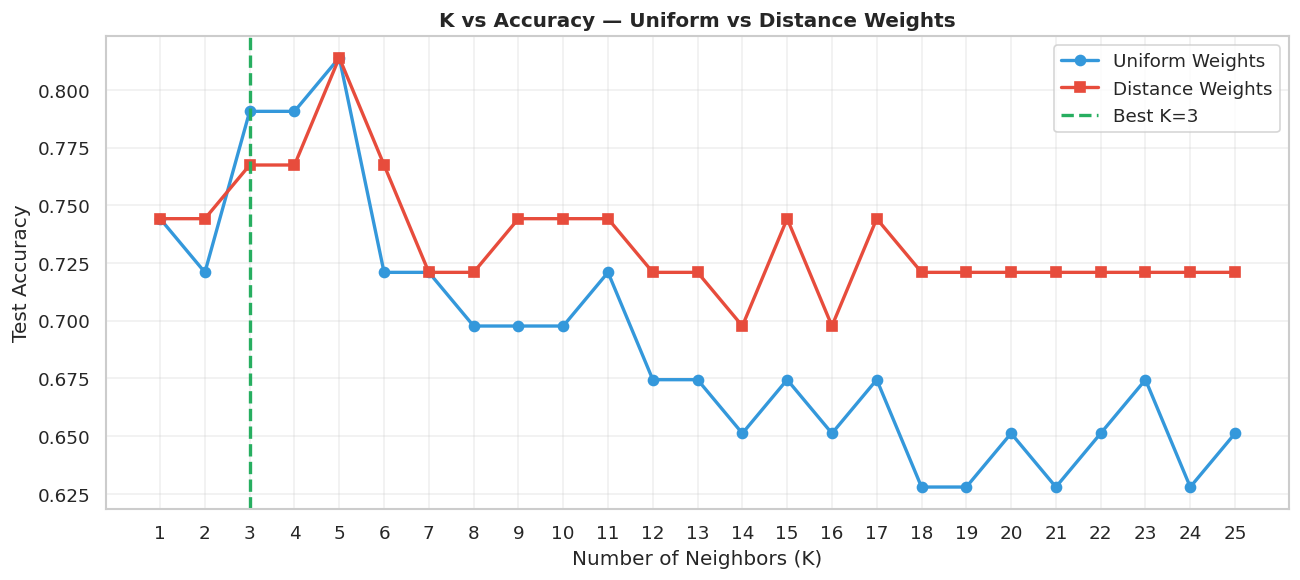

In [31]:
k_range2 = range(1, 26)
acc_uniform  = []
acc_distance = []

for k in k_range2:
    knn_u = KNeighborsClassifier(
        n_neighbors = k,
        weights     = 'uniform',
        metric      = best_metric)
    knn_u.fit(X_train_sc, y_train)
    acc_uniform.append(
        accuracy_score(y_test,
                       knn_u.predict(X_test_sc)))

    knn_d = KNeighborsClassifier(
        n_neighbors = k,
        weights     = 'distance',
        metric      = best_metric)
    knn_d.fit(X_train_sc, y_train)
    acc_distance.append(
        accuracy_score(y_test,
                       knn_d.predict(X_test_sc)))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(k_range2, acc_uniform, 'o-',
        color='#3498db', lw=2,
        label='Uniform Weights')
ax.plot(k_range2, acc_distance, 's-',
        color='#e74c3c', lw=2,
        label='Distance Weights')
ax.axvline(
    x=grid_search.best_params_['n_neighbors'],
    color='#27ae60', linestyle='--', lw=2,
    label=f'Best K='
          f'{grid_search.best_params_["n_neighbors"]}')
ax.set_title('K vs Accuracy — Uniform vs Distance Weights',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Neighbors (K)')
ax.set_ylabel('Test Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, 26))
plt.tight_layout()
plt.savefig('KNN_13_k_weights_comparison.png',
            bbox_inches='tight')
plt.show()

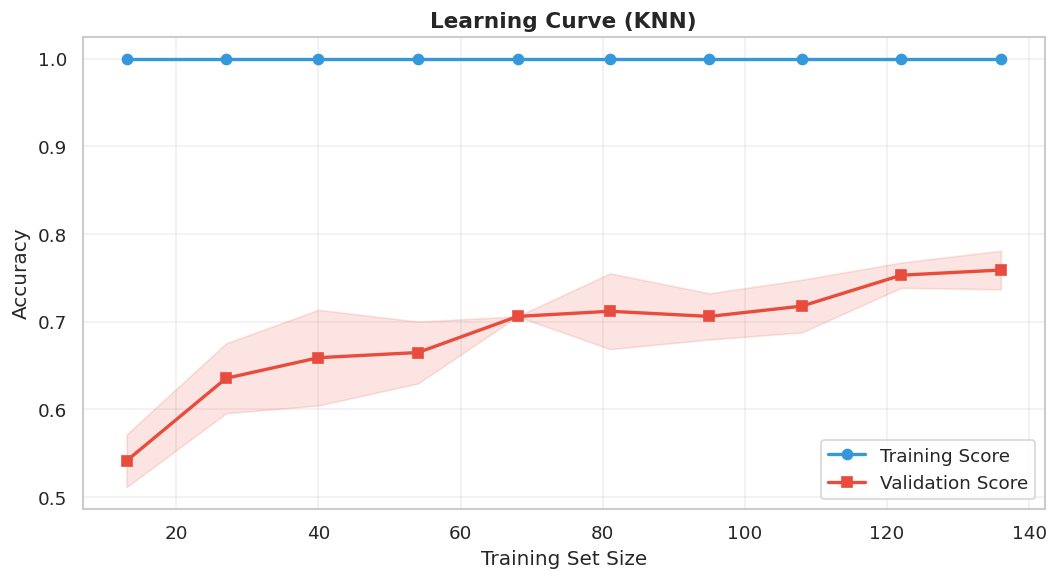

In [32]:
train_sizes, train_sc_lc, val_sc_lc = learning_curve(
    knn_best, X_train_sc, y_train,
    train_sizes = np.linspace(0.1, 1.0, 10),
    cv          = StratifiedKFold(5),
    scoring     = 'accuracy',
    n_jobs      = -1)

train_mean = train_sc_lc.mean(axis=1)
train_std  = train_sc_lc.std(axis=1)
val_mean   = val_sc_lc.mean(axis=1)
val_std    = val_sc_lc.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-',
        color='#3498db', lw=2,
        label='Training Score')
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color='#3498db')
ax.plot(train_sizes, val_mean, 's-',
        color='#e74c3c', lw=2,
        label='Validation Score')
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15, color='#e74c3c')
ax.set_title('Learning Curve (KNN)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Accuracy')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('KNN_14_learning_curve.png',
            bbox_inches='tight')
plt.show()

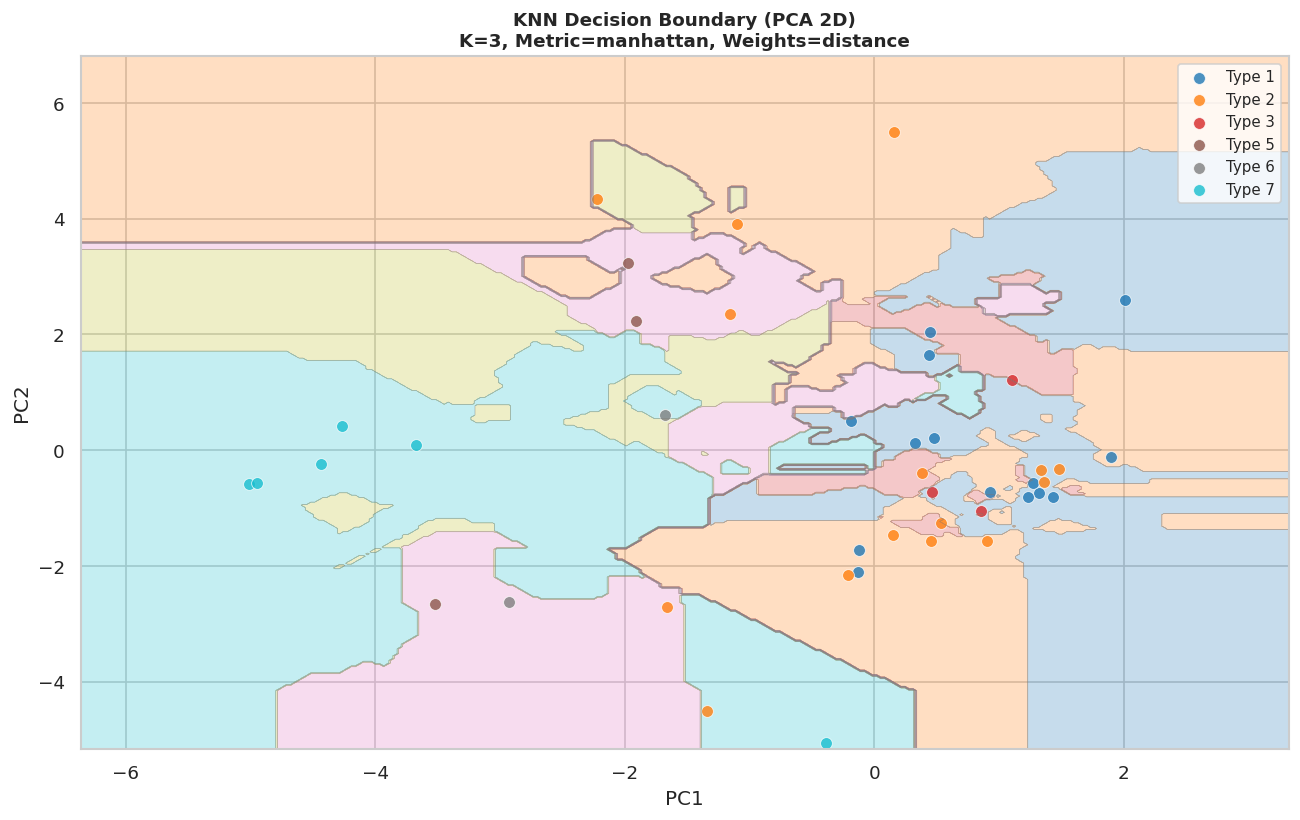

In [33]:
pca_2d     = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train_sc)
X_test_2d  = pca_2d.transform(X_test_sc)

knn_2d = KNeighborsClassifier(
    n_neighbors = grid_search.best_params_['n_neighbors'],
    weights     = grid_search.best_params_['weights'],
    metric      = grid_search.best_params_['metric'])
knn_2d.fit(X_train_2d, y_train)

x_min = X_train_2d[:, 0].min() - 1
x_max = X_train_2d[:, 0].max() + 1
y_min = X_train_2d[:, 1].min() - 1
y_max = X_train_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(11, 7))
ax.contourf(xx, yy, Z,
            cmap='tab10', alpha=0.25)
ax.contour(xx, yy, Z,
           colors='gray',
           linewidths=0.4, alpha=0.6)

unique_types = sorted(y_test.unique())
palette_db   = plt.cm.tab10(
    np.linspace(0, 0.9, len(unique_types)))

for t, color in zip(unique_types, palette_db):
    mask = y_test.values == t
    ax.scatter(X_test_2d[mask, 0],
               X_test_2d[mask, 1],
               c=[color],
               label=f'Type {t}',
               alpha=0.8, s=50,
               edgecolors='white',
               linewidths=0.5)

ax.set_title(
    f'KNN Decision Boundary (PCA 2D)\n'
    f'K={grid_search.best_params_["n_neighbors"]}'
    f', Metric={grid_search.best_params_["metric"]}'
    f', Weights={grid_search.best_params_["weights"]}',
    fontsize=11, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(fontsize=9, loc='best')
plt.tight_layout()
plt.savefig('KNN_15_decision_boundary.png',
            bbox_inches='tight')
plt.show()

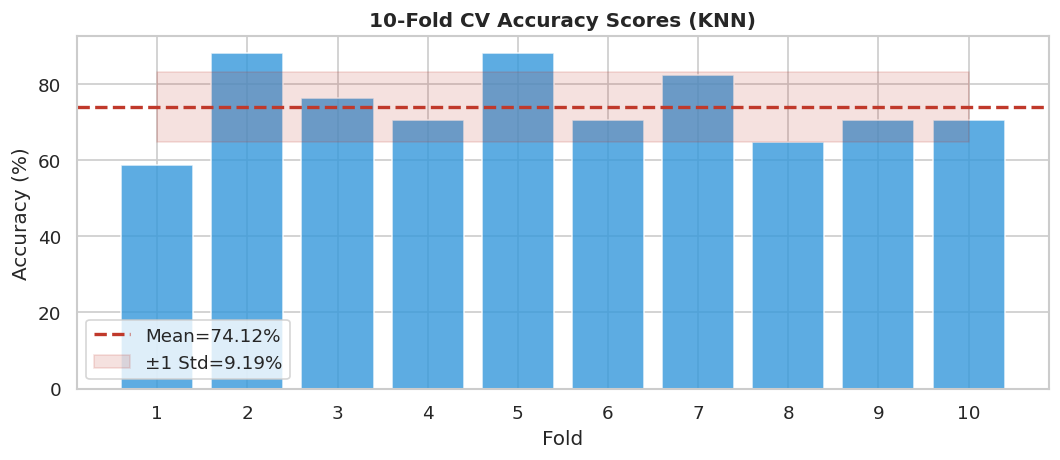

In [34]:
cv_scores_10 = cross_val_score(
    knn_best, X_train_sc, y_train,
    cv=StratifiedKFold(10),
    scoring='accuracy')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, 11), cv_scores_10 * 100,
       color='#3498db', edgecolor='white', alpha=0.8)
ax.axhline(y=cv_scores_10.mean() * 100,
           color='#c0392b', linestyle='--', lw=2,
           label=f'Mean={cv_scores_10.mean()*100:.2f}%')
ax.fill_between(
    range(1, 11),
    (cv_scores_10.mean() - cv_scores_10.std()) * 100,
    (cv_scores_10.mean() + cv_scores_10.std()) * 100,
    alpha=0.15, color='#c0392b',
    label=f'±1 Std={cv_scores_10.std()*100:.2f}%')
ax.set_title('10-Fold CV Accuracy Scores (KNN)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(range(1, 11))
ax.legend()
plt.tight_layout()
plt.savefig('KNN_16_cv_scores.png', bbox_inches='tight')
plt.show()

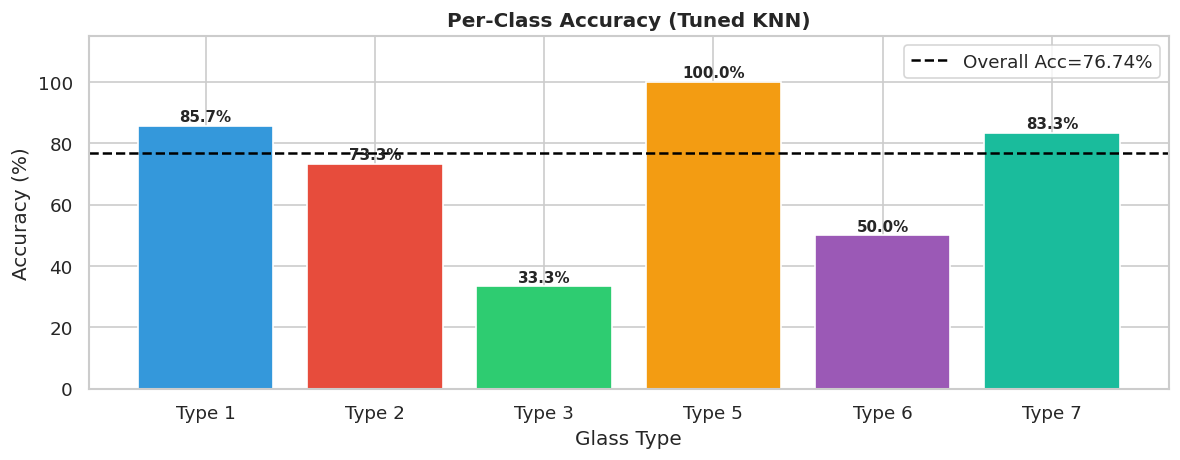

In [35]:
from sklearn.metrics import confusion_matrix

cm_final = confusion_matrix(y_test, y_pred)
per_class_acc = cm_final.diagonal() / cm_final.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    [f"Type {t}" for t in sorted(y.unique())],
    per_class_acc * 100,
    color=colors_pie[:len(sorted(y.unique()))],
    edgecolor='white')
ax.set_title('Per-Class Accuracy (Tuned KNN)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Glass Type')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 115)
ax.axhline(y=acc * 100, color='black',
           linestyle='--', lw=1.5,
           label=f'Overall Acc={acc*100:.2f}%')
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1.5,
            f'{val*100:.1f}%',
            ha='center', fontweight='bold',
            fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig('KNN_17_per_class_accuracy.png',
            bbox_inches='tight')
plt.show()

In [36]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors = grid_search.best_params_[
                          'n_neighbors'],
        weights     = grid_search.best_params_['weights'],
        metric      = grid_search.best_params_['metric'],
        p           = grid_search.best_params_['p']
    ))
])

knn_pipeline.fit(X_train, y_train)

pipe_pred = knn_pipeline.predict(X_test)
pipe_acc  = accuracy_score(y_test, pipe_pred)


In [37]:
# Save tuned KNN model
joblib.dump(knn_best, 'knn_glass_model.pkl')
print("✅ KNN Model saved     → knn_glass_model.pkl")

# Save full pipeline
joblib.dump(knn_pipeline, 'knn_pipeline_glass.pkl')
print("✅ KNN Pipeline saved  → knn_pipeline_glass.pkl")

# Save scaler
joblib.dump(scaler, 'KNN_scaler.pkl')
print("✅ Scaler saved        → KNN_scaler.pkl")

# Save feature names
pd.DataFrame({
    'features': X.columns.tolist()
}).to_csv('KNN_feature_names.csv', index=False)
print("✅ Features saved      → KNN_feature_names.csv")

# Save GridSearch results
pd.DataFrame(
    grid_search.cv_results_
).to_csv('KNN_gridsearch_results.csv', index=False)
print("✅ GridSearch saved    → KNN_gridsearch_results.csv")

# Save K analysis results
k_analysis = pd.DataFrame({
    'K'            : list(k_range),
    'Train_Acc'    : train_accs,
    'Test_Acc'     : test_accs,
    'CV_Acc'       : cv_scores_k,
    'Error_Rate'   : error_rate
})
k_analysis.to_csv('KNN_k_analysis.csv', index=False)
print("✅ K analysis saved    → KNN_k_analysis.csv")

# Save per-class accuracy
per_class_df = pd.DataFrame({
    'Glass_Type'   : [f"Type {t}"
                      for t in sorted(y.unique())],
    'Description'  : [glass_types[t]
                       for t in sorted(y.unique())],
    'Accuracy_pct' : per_class_acc * 100
})
per_class_df.to_csv('KNN_per_class_accuracy.csv',
                    index=False)
print("✅ Per-class acc saved → KNN_per_class_accuracy.csv")

# ── Download in Google Colab ──────────────────────────────────
try:
    from google.colab import files
    files.download('knn_glass_model.pkl')
    files.download('knn_pipeline_glass.pkl')
    files.download('KNN_scaler.pkl')
    files.download('KNN_feature_names.csv')
    files.download('KNN_gridsearch_results.csv')
    files.download('KNN_k_analysis.csv')
    files.download('KNN_per_class_accuracy.csv')
    print("\n🎉 All files downloaded to your PC!")
except ImportError:
    print("\n📁 Not in Colab — saved in current directory:")
    print(f"   → {os.path.abspath('knn_glass_model.pkl')}")
    print(f"   → {os.path.abspath('knn_pipeline_glass.pkl')}")
    print(f"   → {os.path.abspath('KNN_feature_names.csv')}")

✅ KNN Model saved     → knn_glass_model.pkl
✅ KNN Pipeline saved  → knn_pipeline_glass.pkl
✅ Scaler saved        → KNN_scaler.pkl
✅ Features saved      → KNN_feature_names.csv
✅ GridSearch saved    → KNN_gridsearch_results.csv
✅ K analysis saved    → KNN_k_analysis.csv
✅ Per-class acc saved → KNN_per_class_accuracy.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 All files downloaded to your PC!


In [38]:
loaded_pipeline = joblib.load('knn_pipeline_glass.pkl')

sample      = X_test.iloc[:6]
predictions = loaded_pipeline.predict(sample)
proba       = loaded_pipeline.predict_proba(sample)
actuals     = y_test.values[:6]

print("\n📊 Sample Predictions:")
print(f"{'#':<4} {'Predicted':<10} {'Actual':<10}"
      f" {'Correct':<10} {'Confidence':>12}")
print("-" * 50)

for i, (pred, prob, actual) in enumerate(
        zip(predictions, proba, actuals)):
    correct    = "✅" if pred == actual else "❌"
    confidence = prob.max() * 100
    print(f"{i+1:<4} Type {pred:<5} "
          f"Type {actual:<5} "
          f"{correct:<10} {confidence:>10.2f}%")

print("\n✅ Model loaded and working perfectly!")


📊 Sample Predictions:
#    Predicted  Actual     Correct      Confidence
--------------------------------------------------
1    Type 7     Type 7     ✅              100.00%
2    Type 5     Type 5     ✅               74.59%
3    Type 2     Type 2     ✅              100.00%
4    Type 5     Type 5     ✅               98.69%
5    Type 1     Type 1     ✅              100.00%
6    Type 2     Type 1     ❌              100.00%

✅ Model loaded and working perfectly!


In [39]:

print(f"  Dataset             : Glass Type Classification")
print(f"  Dataset Shape       : {df.shape}")
print(f"  Number of Classes   : {y.nunique()} types")
print(f"  Features Used       : {X.shape[1]}")
print(f"  Training Samples    : {X_train_sc.shape[0]}")
print(f"  Test Samples        : {X_test_sc.shape[0]}")
print(f"  Best K              : "
      f"{grid_search.best_params_['n_neighbors']}")
print(f"  Best Metric         : "
      f"{grid_search.best_params_['metric']}")
print(f"  Best Weights        : "
      f"{grid_search.best_params_['weights']}")
print(f"  Baseline Accuracy   : {acc_base*100:.2f}%")
print(f"  Tuned Accuracy      : {acc*100:.2f}%")
print(f"  ROC-AUC (weighted)  : {roc:.4f}")
print(f"  CV Accuracy         : "
      f"{cv.mean()*100:.2f}% ± {cv.std()*100:.2f}%")

print(" Saved Files:")
print("   knn_glass_model.pkl")
print("   knn_pipeline_glass.pkl  ← Production use!")
print("   KNN_scaler.pkl")
print("   KNN_feature_names.csv")
print("   KNN_gridsearch_results.csv")
print("   KNN_k_analysis.csv")
print("   KNN_per_class_accuracy.csv")
print("    KNN_01 ~ KNN_17 PNG files")

print(" KNN Pipeline Complete! ")

  Dataset             : Glass Type Classification
  Dataset Shape       : (213, 10)
  Number of Classes   : 6 types
  Features Used       : 14
  Training Samples    : 170
  Test Samples        : 43
  Best K              : 3
  Best Metric         : manhattan
  Best Weights        : distance
  Baseline Accuracy   : 76.74%
  Tuned Accuracy      : 76.74%
  ROC-AUC (weighted)  : 0.9251
  CV Accuracy         : 75.88% ± 2.20%
 Saved Files:
   knn_glass_model.pkl
   knn_pipeline_glass.pkl  ← Production use!
   KNN_scaler.pkl
   KNN_feature_names.csv
   KNN_gridsearch_results.csv
   KNN_k_analysis.csv
   KNN_per_class_accuracy.csv
    KNN_01 ~ KNN_17 PNG files
 KNN Pipeline Complete! 
